In [1]:
# Librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Constantes
from scipy.constants import mu_0, pi

# Estilo de las gráficas
sns.set_theme()


In [2]:
def calcular_regresion_lineal(x, y):
    
    coeficientes_led, M_cov = np.polyfit(x, y, 1, cov=True)
    m, b = coeficientes_led
    error_m, error_b = np.sqrt(np.diag(M_cov))

    print(
        f'''Regresión lineal:
{'-'*40}
Pendiente (m): ({m : .4g} ± {error_m: .4g})
Intercepto (b): ({b : .4g} ± {error_b : .4g})'''
    )

    return m, b, error_m, error_b

In [3]:
ruta_archivo = r'datos_sensor_fabricante.txt'

datos_fabricante_df = pd.read_csv(
    ruta_archivo, sep=',',
    skiprows=3, 
    names=[
        'intensidad_mT',
        'voltaje_V'
    ], 
    dtype={
        'intensidad_mT': np.float64,
        'voltaje_V': np.float64
    }, 
    index_col=False,  
    engine='python'
)

datos_fabricante_df

,intensidad_mT,voltaje_V
0,-100.0,0.86
1,-80.0,1.20
2,-60.0,1.40
3,-40.0,1.70
4,-20.0,2.10
5,0.0,2.50
6,20.0,2.70
7,40.0,3.10
8,60.0,3.40
9,80.0,3.80


In [4]:
x = datos_fabricante_df.intensidad_mT 
y = datos_fabricante_df.voltaje_V

m, b, error_m, error_b = calcular_regresion_lineal(x,y)


Regresión lineal:
----------------------------------------
Pendiente (m): ( 0.01661 ±  0.0003318)
Intercepto (b): ( 2.452 ±  0.02098)


In [5]:
radio_m = 1/10
n_vueltas = 20
corriente_A = 2

corriente_0_A = 1
corriente_f_A = 4.0
delta_i_A = 0.2

radio_0_m = 0.05
radio_f_m = 0.5
delta_r_m = 0.05

corrientes_simuladas_A = np.arange(corriente_0_A, corriente_f_A + delta_i_A, delta_i_A)
radios_simulados_m = np.arange(radio_0_m, radio_f_m + delta_r_m, delta_r_m)

# Bobinas de Helmholtz: B con corriente variable
B_corriente_simulado_mT = (2 * mu_0 * n_vueltas * corrientes_simuladas_A) / (radio_m * np.sqrt(5)) *1e3

# Bobinas de Helmholtz: B con radio variable
B_radio_simulado_mT = (2 * mu_0 * n_vueltas * corriente_A) / (radios_simulados_m * np.sqrt(5)) *1e3

# Alambre "infinito"
# B_corriente_simulado_mT = (corrientes_simuladas_A * mu_0) / (2 * pi * radio_m) * 1e3 

B_corriente_simulado_mT

array([0.22479407, 0.26975289, 0.3147117 , 0.35967051, 0.40462933,
       0.44958814, 0.49454696, 0.53950577, 0.58446459, 0.6294234 ,
       0.67438221, 0.71934103, 0.76429984, 0.80925866, 0.85421747,
       0.89917629])

In [6]:
voltaje_B_corriente_simulado = m * B_corriente_simulado_mT + b

voltaje_B_corriente_simulado_arduino = voltaje_B_corriente_simulado.round(5)
voltaje_B_corriente_simulado_arduino

array([2.45555, 2.4563 , 2.45705, 2.45779, 2.45854, 2.45929, 2.46003,
       2.46078, 2.46153, 2.46228, 2.46302, 2.46377, 2.46452, 2.46526,
       2.46601, 2.46676])

In [7]:
voltaje_B_radio_simulado = m * B_radio_simulado_mT + b

voltaje_B_radio_simulado_arduino = voltaje_B_radio_simulado.round(5)
voltaje_B_radio_simulado_arduino

array([2.46676, 2.45929, 2.4568 , 2.45555, 2.45481, 2.45431, 2.45395,
       2.45369, 2.45348, 2.45331])

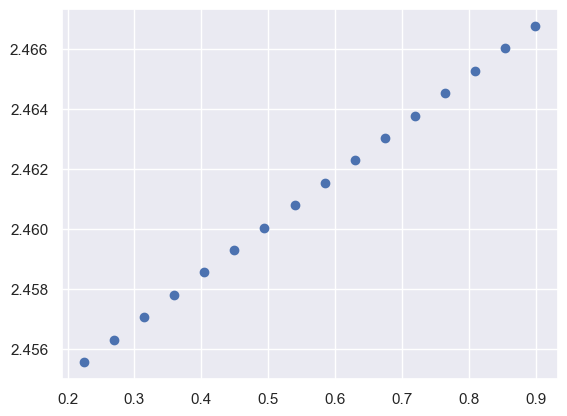

In [8]:
plt.scatter(B_corriente_simulado_mT, voltaje_B_corriente_simulado_arduino)

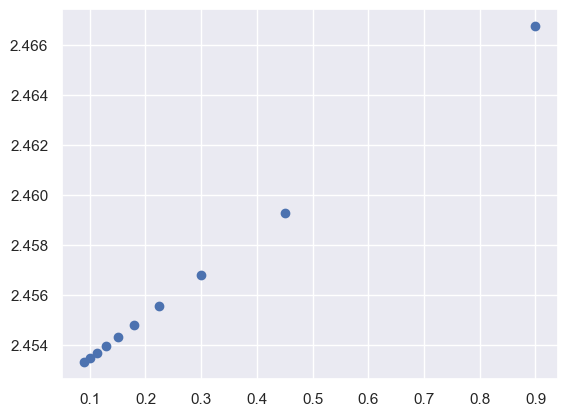

In [9]:
plt.scatter(B_radio_simulado_mT, voltaje_B_radio_simulado_arduino)

In [10]:
len(voltaje_B_corriente_simulado_arduino), len(voltaje_B_radio_simulado_arduino)

(16, 10)

In [14]:
x = np.array([-1500, 0, 1500])
y = np.array([0.86, 2.25, 4.21])

calcular_regresion_lineal(x,y)

Regresión lineal:
----------------------------------------
Pendiente (m): ( 0.001117 ±  0.0001097)
Intercepto (b): ( 2.44 ±  0.1344)


(np.float64(0.0011166666666666664),
 np.float64(2.44),
 np.float64(0.00010969655114602885),
 np.float64(0.13435028842544397))